In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

# --- 1. Load Your Processed Datasets ---
print("Loading processed datasets...")
nhanes_df = pd.read_csv('../data/03_processed/nhanes_final.csv')
brfss_df = pd.read_csv('../data/03_processed/brfss_final.csv')

# --- 2. Define the Common Feature Set ---
# This is the list of features the model will be trained and tested on
common_features = [
    'Age', 'Gender', 'Race_Ethnicity', 'BMI', 'Smoking_Status',
    'Physical_Activity', 'History_Heart_Attack', 'History_Stroke'
]

# --- 3. Prepare the Training and Testing Data ---
# Prepare NHANES (Training Data)
nhanes_df.dropna(subset=['Diabetes_Outcome'], inplace=True)
X_train = nhanes_df[common_features]
y_train = nhanes_df['Diabetes_Outcome']

# Prepare BRFSS (External Testing Data)
brfss_df.dropna(subset=['Diabetes_Outcome'], inplace=True)
X_test = brfss_df[common_features]
y_test = brfss_df['Diabetes_Outcome']

print("Datasets loaded and prepared.")

# --- 4. Define Your Final, Optimized XGBoost Model ---
# We use the best hyperparameters we just found
final_xgb_model = xgb.XGBClassifier(
    learning_rate=0.05,
    max_depth=3,
    n_estimators=200,
    random_state=42,
    eval_metric='logloss'
)
print("Final XGBoost model defined with best hyperparameters.")

# --- 5. Impute Missing Values ---
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)
print("Imputation complete.")

# --- 6. Train Model on Full NHANES and Predict on BRFSS ---
print("Training final model on the full NHANES dataset...")
final_xgb_model.fit(X_train_imputed, y_train)
print("Making predictions on the external BRFSS dataset...")
y_pred_proba_brfss = final_xgb_model.predict_proba(X_test_imputed)[:, 1]
print("Prediction complete.")

# --- 7. Evaluate External Validation Performance ---
auc_internal = 0.8760  # The winning score from our last notebook
auc_external = roc_auc_score(y_test, y_pred_proba_brfss)
performance_drop = auc_internal - auc_external

print("\n--- External Validation Results ---")
print(f"Internal Validation AUC (NHANES): {auc_internal:.4f}")
print(f"External Validation AUC (BRFSS):  {auc_external:.4f}")
print(f"Performance Drop:                 {performance_drop:.4f}")

Loading processed datasets...
Datasets loaded and prepared.
Final XGBoost model defined with best hyperparameters.
Imputation complete.
Training final model on the full NHANES dataset...
Making predictions on the external BRFSS dataset...
Prediction complete.

--- External Validation Results ---
Internal Validation AUC (NHANES): 0.8760
External Validation AUC (BRFSS):  0.7134
Performance Drop:                 0.1626


--- 1. Calibration Analysis ---
Brier Score: 0.1315


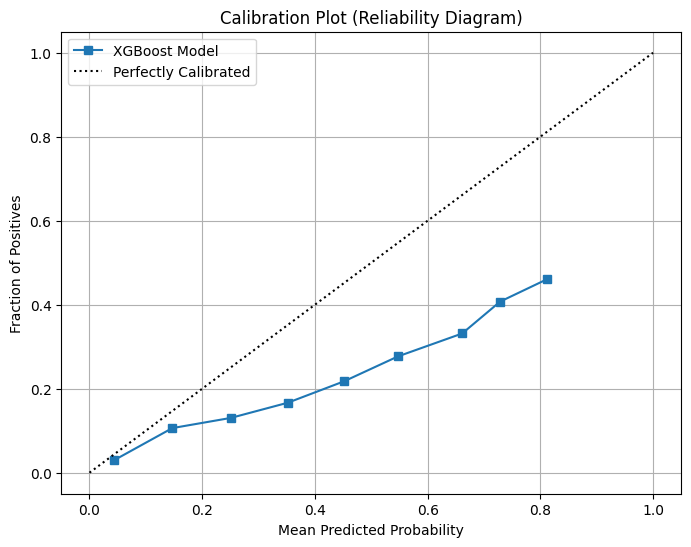

In [3]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

print("--- 1. Calibration Analysis ---")

# Calculate the Brier score: a measure of accuracy for probabilistic predictions. Lower is better.
brier_score = brier_score_loss(y_test, y_pred_proba_brfss)
print(f"Brier Score: {brier_score:.4f}")

# Calculate data for the calibration plot
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_pred_proba_brfss, n_bins=10)

# Create the calibration plot
plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label='XGBoost Model')
plt.plot([0, 1], [0, 1], "k:", label='Perfectly Calibrated')

plt.title('Calibration Plot (Reliability Diagram)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.grid(True)
plt.show()


--- 2. Decision Curve Analysis (DCA) ---


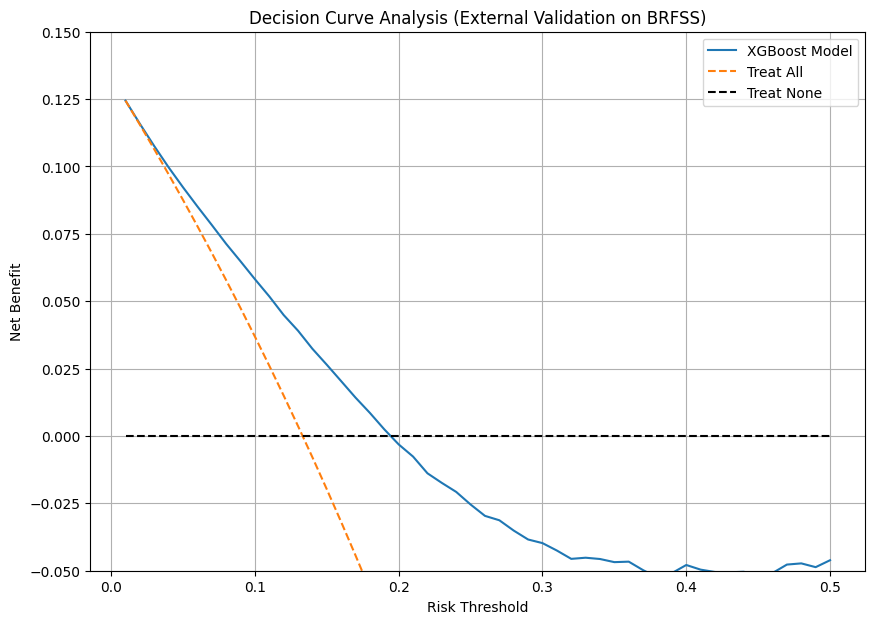

In [4]:
print("\n--- 2. Decision Curve Analysis (DCA) ---")

def calculate_net_benefit(y_true, y_pred_proba, thresholds):
    """Calculates the net benefit for a model over a range of thresholds."""
    net_benefit = []
    for t in thresholds:
        # Classify based on threshold
        y_pred = (y_pred_proba >= t).astype(int)
        
        n = len(y_true)
        true_positives = np.sum(y_pred[y_true == 1])
        false_positives = np.sum(y_pred[y_true == 0])
        
        nb = (true_positives / n) - (false_positives / n) * (t / (1 - t))
        net_benefit.append(nb)
    return net_benefit

# Define a range of risk thresholds to evaluate (e.g., 1% to 50%)
thresholds = np.arange(0.01, 0.51, 0.01)

# Calculate net benefit for the model
net_benefit_model = calculate_net_benefit(y_test, y_pred_proba_brfss, thresholds)

# Calculate net benefit for the "treat all" strategy
prevalence = np.mean(y_test)
net_benefit_all = [prevalence - (1 - prevalence) * (t / (1 - t)) for t in thresholds]

# Create the DCA plot
plt.figure(figsize=(10, 7))
plt.plot(thresholds, net_benefit_model, label='XGBoost Model')
plt.plot(thresholds, net_benefit_all, label='Treat All', linestyle='--')
plt.hlines(y=0, xmin=0.01, xmax=0.5, label='Treat None', color='black', linestyle='--')

plt.title('Decision Curve Analysis (External Validation on BRFSS)')
plt.xlabel('Risk Threshold')
plt.ylabel('Net Benefit')
plt.ylim(-0.05, 0.15) # Adjust y-axis for better visibility
plt.legend()
plt.grid(True)
plt.show()

In [5]:
# Run this cell once to install the shap library
%pip install shap

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/545.1 kB ? eta -:--:--
   ---------------------------------------- 545.1/545.1 kB 6.9 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   -------------------------------------- - 2.6/2.7 MB 12.8 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 12.2 MB/s  0:00:00
   ---------------------------------------- 0.0/37.9 MB ? eta -:--:--
   --- ------------------------------------ 3.4/37.9 MB 16.4 MB/s eta 0:00:03
   ------ --------------------------------- 6.0/37.9 MB 14.5 MB/s eta 0:00:03
   -------- ------------------------------- 8.4/37.9 MB 14.0 MB/s eta 0:00:03
   -------

Global Feature Importance

c:\diabetes_prediction_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Calculating SHAP values...
SHAP values calculated.


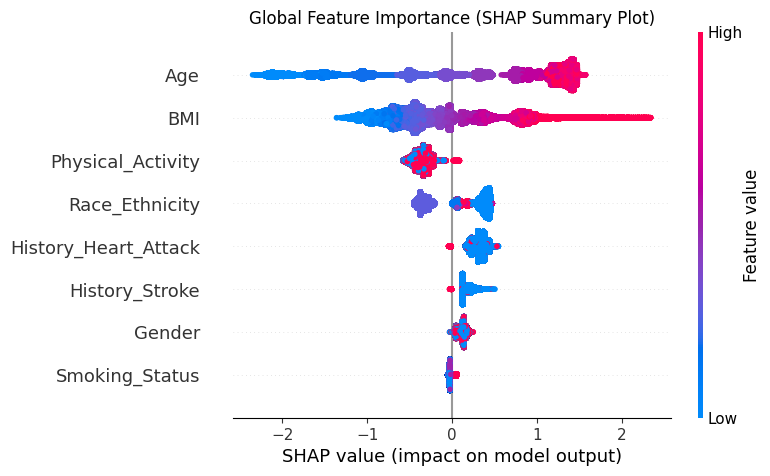

In [6]:
import shap

# --- Create a SHAP Explainer ---
# We use a TreeExplainer for XGBoost, which is fast and accurate
explainer = shap.TreeExplainer(final_xgb_model)

# --- Calculate SHAP values for the test set ---
# This can take a minute or two
print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_test_imputed)
print("SHAP values calculated.")

# --- Create the SHAP Summary Plot ---
# We pass the original X_test to get the real feature names on the plot
X_test_df_for_plot = pd.DataFrame(X_test_imputed, columns=X_test.columns)
shap.summary_plot(shap_values, X_test_df_for_plot, show=False)
plt.title("Global Feature Importance (SHAP Summary Plot)")
plt.show()

Fairness Analysis(Subgroup Performance Analysis)

In [7]:
# We need the original BRFSS dataframe to get the demographic columns
# Let's align the predictions with the original dataframe
brfss_df_with_preds = brfss_df.copy()
brfss_df_with_preds['predictions'] = y_pred_proba_brfss

print("--- Fairness Analysis: Performance by Subgroup ---")

# --- Analyze by Gender ---
print("\n--- By Gender ---")
# Note: In our cleaned data, 0=Male, 1=Female
gender_map = {0: 'Male', 1: 'Female'} 
for gender_code, gender_name in gender_map.items():
    subgroup_df = brfss_df_with_preds[brfss_df_with_preds['Gender'] == gender_code]
    subgroup_auc = roc_auc_score(subgroup_df['Diabetes_Outcome'], subgroup_df['predictions'])
    print(f"AUC for {gender_name}: {subgroup_auc:.4f}")

# --- Analyze by Race/Ethnicity ---
print("\n--- By Race/Ethnicity ---")
# Note: Check your codebook for the specific mapping of these numeric codes
race_map = {
    1: 'White, Non-Hispanic',
    2: 'Black, Non-Hispanic',
    3: 'Other race, Non-Hispanic',
    4: 'Multiracial, Non-Hispanic',
    5: 'Hispanic'
}
for race_code, race_name in race_map.items():
    subgroup_df = brfss_df_with_preds[brfss_df_with_preds['Race_Ethnicity'] == race_code]
    # Check if there are both outcomes present in the subgroup to avoid errors
    if len(subgroup_df['Diabetes_Outcome'].unique()) > 1:
        subgroup_auc = roc_auc_score(subgroup_df['Diabetes_Outcome'], subgroup_df['predictions'])
        print(f"AUC for {race_name}: {subgroup_auc:.4f}")
    else:
        print(f"Could not calculate AUC for {race_name} (only one outcome class present).")

--- Fairness Analysis: Performance by Subgroup ---

--- By Gender ---
AUC for Male: 0.7188
AUC for Female: 0.7082

--- By Race/Ethnicity ---
AUC for White, Non-Hispanic: 0.7403
AUC for Black, Non-Hispanic: 0.7213
AUC for Other race, Non-Hispanic: 0.7174
AUC for Multiracial, Non-Hispanic: 0.7960
AUC for Hispanic: 0.7523


In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, brier_score_loss
from sklearn.impute import SimpleImputer
import xgboost as xgb

print("Starting the External Validation process...")

# --- 1. Load Datasets ---
nhanes_filepath = r'C:\diabetes_prediction_project\data\03_processed\nhanes_final.csv'
brfss_filepath = r'C:\diabetes_prediction_project\data\03_processed\brfss_final.csv'

df_nhanes = pd.read_csv(nhanes_filepath)
df_brfss = pd.read_csv(brfss_filepath)
print("Successfully loaded NHANES and BRFSS datasets.")

# --- FIX: Remove rows where the outcome is missing from both datasets ---
# This is the line that will solve the ValueError
df_nhanes.dropna(subset=['Diabetes_Outcome'], inplace=True)
df_brfss.dropna(subset=['Diabetes_Outcome'], inplace=True)
print(f"Cleaned datasets. New BRFSS shape: {df_brfss.shape}")

# --- 2. Prepare Data ---
common_features = [
    'Age', 'Gender', 'Race_Ethnicity', 'BMI', 'Smoking_Status',
    'Physical_Activity', 'History_Heart_Attack', 'History_Stroke'
]

X_train = df_nhanes[common_features]
y_train = df_nhanes['Diabetes_Outcome']

X_test = df_brfss[common_features]
y_test = df_brfss['Diabetes_Outcome']

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)
print("Data imputation complete.")

# --- 3. Train the Final Model ---
final_xgb = xgb.XGBClassifier(
    learning_rate=0.05,
    max_depth=3,
    n_estimators=200,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

print("Training final XGBoost model on the entire NHANES dataset...")
final_xgb.fit(X_train_imputed, y_train)
print("Training complete.")

# --- 4. Evaluate on External Data (BRFSS) ---
print("Evaluating model on the external BRFSS dataset...")
y_pred_proba = final_xgb.predict_proba(X_test_imputed)[:, 1]

# --- Calculate BRFSS Metrics ---
brfss_auc = roc_auc_score(y_test, y_pred_proba)
brfss_brier = brier_score_loss(y_test, y_pred_proba)

# From the feedback doc, the optimal threshold was 0.184.
optimal_threshold = 0.184
y_pred_class = (y_pred_proba >= optimal_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_class).ravel()
brfss_sensitivity = tp / (tp + fn)
brfss_specificity = tn / (tn + fp)
brfss_precision = tp / (tp + fp)
brfss_npv = tn / (tn + fn)
brfss_f1 = 2 * (brfss_precision * brfss_sensitivity) / (brfss_precision + brfss_sensitivity)
brfss_accuracy = (tp + tn) / (tp + tn + fp + fn)

# --- 5. Display and Save the Results ---
print("\n--- External Validation Results on BRFSS ---")
print(f"AUC: {brfss_auc:.4f}")
print(f"Brier Score: {brfss_brier:.4f}")
print(f"At threshold={optimal_threshold}:")
print(f"  Accuracy: {brfss_accuracy:.4f}")
print(f"  Sensitivity (Recall): {brfss_sensitivity:.4f}")
print(f"  Specificity: {brfss_specificity:.4f}")
print(f"  Precision (PPV): {brfss_precision:.4f}")
print(f"  NPV: {brfss_npv:.4f}")
print(f"  F1 Score: {brfss_f1:.4f}")

brfss_results = {
    'AUC': brfss_auc, 'Brier Score': brfss_brier, 'Accuracy': brfss_accuracy,
    'Sensitivity': brfss_sensitivity, 'Specificity': brfss_specificity,
    'PPV': brfss_precision, 'NPV': brfss_npv, 'F1 Score': brfss_f1
}
# Convert to DataFrame and save
pd.DataFrame([brfss_results]).to_csv('results/external_validation_results.csv', index=False)
print("\nExternal validation results saved to 'results/external_validation_results.csv'")

Starting the External Validation process...
Successfully loaded NHANES and BRFSS datasets.
Cleaned datasets. New BRFSS shape: (1282897, 10)
Data imputation complete.
Training final XGBoost model on the entire NHANES dataset...


c:\diabetes_prediction_project\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:09:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training complete.
Evaluating model on the external BRFSS dataset...

--- External Validation Results on BRFSS ---
AUC: 0.7172
Brier Score: 0.1239
At threshold=0.184:
  Accuracy: 0.5417
  Sensitivity (Recall): 0.7982
  Specificity: 0.5023
  Precision (PPV): 0.1977
  NPV: 0.9419
  F1 Score: 0.3169

External validation results saved to 'results/external_validation_results.csv'


In [3]:
# --- FINAL SCRIPT FOR 03_external_validation.ipynb ---
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, brier_score_loss, confusion_matrix
from sklearn.impute import SimpleImputer
import xgboost as xgb

print("Starting the External Validation process...")
nhanes_filepath = r'C:\diabetes_prediction_project\data\03_processed\nhanes_final.csv'
brfss_filepath = r'C:\diabetes_prediction_project\data\03_processed\brfss_final.csv'
df_nhanes = pd.read_csv(nhanes_filepath)
df_brfss = pd.read_csv(brfss_filepath)
df_nhanes.dropna(subset=['Diabetes_Outcome'], inplace=True)
df_brfss.dropna(subset=['Diabetes_Outcome'], inplace=True)
common_features = ['Age', 'Gender', 'Race_Ethnicity', 'BMI', 'Smoking_Status', 'Physical_Activity', 'History_Heart_Attack', 'History_Stroke']
X_train, y_train = df_nhanes[common_features], df_nhanes['Diabetes_Outcome']
X_test, y_test = df_brfss[common_features], df_brfss['Diabetes_Outcome']
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)
final_xgb = xgb.XGBClassifier(learning_rate=0.05, max_depth=3, n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=42)
print("Training final XGBoost model...")
final_xgb.fit(X_train_imputed, y_train)
print("Evaluating model on the external BRFSS dataset...")
y_pred_proba = final_xgb.predict_proba(X_test_imputed)[:, 1]

# <<< NEW: Save predictions for external validation >>>
external_preds_df = pd.DataFrame({'y_true': y_test, 'y_pred_proba': y_pred_proba})
external_preds_df.to_csv('results/external_validation_predictions.csv', index=False)
print("\nRaw predictions from external validation saved to 'results/external_validation_predictions.csv'")

# (The rest of the script to print summary metrics is the same)
brfss_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n--- External Validation Results on BRFSS ---")
print(f"AUC: {brfss_auc:.4f}")

Starting the External Validation process...
Training final XGBoost model...


c:\diabetes_prediction_project\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:54:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Evaluating model on the external BRFSS dataset...

Raw predictions from external validation saved to 'results/external_validation_predictions.csv'

--- External Validation Results on BRFSS ---
AUC: 0.7172
